# Cross-Modal Medical Image Synthesis using Schrödinger Bridge Flow Matching (SB-CFM)

Welcome to this tutorial on synthesizing medical imaging modalities. In clinical settings, we often possess one modality (e.g., a structural T1-MRI) but require another (e.g., a T2-MRI or CT) for radiation therapy planning or comprehensive diagnosis. Collecting paired data is expensive and time-consuming.

In this notebook, we will use **Schrödinger Bridge Flow Matching (SB-CFM)** to learn a mapping from a Source Modality to a Target Modality. We will optimize our workflow for an NVIDIA T4 GPU (common in Google Colab) by utilizing 2D slices and Automatic Mixed Precision (AMP).

## Section 1: Setup & Dependencies

First, we will install the necessary frameworks. We are using **MONAI** for medical-specific neural network blocks and data transformations, and **torchcfm** for Flow Matching utilities.

In [29]:
# Install required libraries
!pip install -q monai torchcfm nibabel tqdm torchmetrics matplotlib

import os
import math
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# MONAI imports
import monai
from monai.networks.nets import BasicUNet
from monai.transforms import (
    Compose, EnsureChannelFirst, ScaleIntensity, Resize, ToTensor
)
from monai.data import Dataset, DataLoader

# Metrics
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics import MeanAbsoluteError

# Configure Device and Seeds for Reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

monai.utils.set_determinism(seed=42)
torch.manual_seed(42)

Using device: cuda


## Section 2: The Dataset (Cross-Modal Proxy)

To make this tutorial self-contained and executable without downloading large databases (like IXI or BraTS), we will generate a synthetic paired dataset.

* **Modality A (Source)**: Simulated T1-MRI (hypointense fluid, hyperintense fat).
* **Modality B (Target)**: Simulated T2-MRI/CT (hyperintense fluid).

We apply a MONAI transformation pipeline to normalize, resize to 128x128 (to ensure a light memory footprint on the T4 GPU), and convert the 2D slices to tensors.

In [36]:
from monai.data.synthetic import create_test_image_2d

class PairedSyntheticDataset(Dataset):
    def __init__(self, num_samples=250, transform=None):
        self.num_samples = num_samples
        self.transform = transform

        # Generate dummy 2D slices acting as T1 and T2 pairs
        self.data = []
        for i in range(num_samples):
            # create_test_image_2d returns (image, label)
            # We vary the parameters slightly to simulate anatomical variance
            img_t1, _ = create_test_image_2d(128, 128, num_objs=4, rad_max=20, noise_max=0.1)
            img_t2, _ = create_test_image_2d(128, 128, num_objs=4, rad_max=20, noise_max=0.1)

            # Simulate contrast inversion often seen between T1/T2
            img_t2 = 1.0 - img_t1 + np.random.normal(0, 0.05, (128, 128))

            # Save temporary files to mimic a real file-loading pipeline
            t1_path = f"/tmp/t1_{i}.npy"
            t2_path = f"/tmp/t2_{i}.npy"
            np.save(t1_path, img_t1)
            np.save(t2_path, img_t2)
            self.data.append({"source": t1_path, "target": t2_path})

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        item = self.data[idx]
        src_img = np.load(item["source"])[np.newaxis, ...] # Add channel dim
        tgt_img = np.load(item["target"])[np.newaxis, ...]

        if self.transform:
            src_img = self.transform(src_img)
            tgt_img = self.transform(tgt_img)

        return {"source": src_img, "target": tgt_img}

# Define the MONAI Pipeline
transforms = Compose([
    ScaleIntensity(),
    Resize((128, 128)),
    ToTensor(dtype=torch.float32)
])

# Create DataLoaders
dataset = PairedSyntheticDataset(num_samples=400, transform=transforms)
# Set num_workers=0 to avoid multiprocessing assertion errors in interactive environments
train_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0)
print("Dataset initialized and Dataloader ready.")

Dataset initialized and Dataloader ready.


## Section 3: Mathematical Intuition

Unlike standard Denoising Diffusion Probabilistic Models (DDPMs) that learn to map pure Gaussian noise to a data distribution, **Schrödinger Bridge Flow Matching (SB-CFM)** formulates a direct, deterministic bridge between two arbitrary distributions (Modality A $\to$ Modality B).

Given a source image $x_0$ and a target image $x_1$, we construct a linear probability path:


$$x_t = (1-t)x_0 + tx_1$$

The target vector field that drives this straight-line transport is simply the constant velocity between the two states:


$$u_t(x|x_0, x_1) = x_1 - x_0$$

Our neural network, $v_\theta(x_t, t)$, is trained to predict this vector field. The Conditional Flow Matching objective is:


$$\mathcal{L}_{CFM}(\theta) = \mathbb{E}_{t, q_t(x|x_0, x_1)} [\| v_\theta(x_t, t) - u_t(x|x_0, x_1) \|^2]$$

By integrating the learned vector field $v_\theta$ over time $t \in [0, 1]$, we map a source MRI to its synthetic target counterpart.

## Section 4: Model Architecture

We wrap MONAI's robust `BasicUNet` to accept a continuous time variable $t$. We utilize Sinusoidal Position Embeddings to encode $t$, projecting the embeddings spatially so they can be concatenated to the structural input $x_t$.

In [31]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class TimeConditionalUNet(nn.Module):
    def __init__(self, spatial_dims=2, in_channels=1, out_channels=1, time_emb_dim=16):
        super().__init__()

        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.GELU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # MONAI BasicUNet - Notice in_channels + time_emb_dim
        self.unet = BasicUNet(
            spatial_dims=spatial_dims,
            in_channels=in_channels + time_emb_dim,
            out_channels=out_channels,
            features=(32, 64, 128, 256, 128, 32),
            dropout=0.1
        )

    def forward(self, x, t):
        # 1. Compute time embeddings: [Batch, Time_Dim]
        t_emb = self.time_mlp(t)

        # 2. Expand spatially: [Batch, Time_Dim, H, W]
        t_map = t_emb.view(t.shape[0], -1, 1, 1).expand(-1, -1, x.shape[2], x.shape[3])

        # 3. Concatenate structural input with time embeddings
        x_in = torch.cat([x, t_map], dim=1)

        # 4. Predict vector field
        return self.unet(x_in)

model = TimeConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

BasicUNet features: (32, 64, 128, 256, 128, 32).


## Section 5: Flow Matching Training Loop

Here, we implement the training step. We sample $x_0$ and $x_1$, draw a random time $t \sim \text{Uniform}(0, 1)$, and construct $x_t$. We use **Automatic Mixed Precision (AMP)** via `torch.cuda.amp` to maximize memory efficiency and compute speed on the T4 GPU.

In [ ]:
epochs = 25
scaler = GradScaler()
model.train()

loss_history = []

print("Starting SB-CFM Training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in progress_bar:
        optimizer.zero_grad()

        # Move data to GPU
        x_0 = batch["source"].to(device)  # Source Modality
        x_1 = batch["target"].to(device)  # Target Modality

        batch_size = x_0.shape[0]

        # Sample random time t ~ U(0, 1)
        t = torch.rand(batch_size, device=device)
        t_expand = t.view(-1, 1, 1, 1) # Reshape for broadcasting

        # Construct the linear interpolation (probability path)
        x_t = (1 - t_expand) * x_0 + t_expand * x_1

        # The target vector field (Optimal Transport)
        u_t = x_1 - x_0

        # Predict the vector field using AMP
        with autocast():
            v_pred = model(x_t, t)
            loss = torch.nn.functional.mse_loss(v_pred, u_t)

        # Backward pass with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        progress_bar.set_postfix({"MSE Loss": f"{loss.item():.4f}"})

    loss_history.append(epoch_loss / len(train_loader))

plt.plot(loss_history)
plt.title("CFM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Starting SB-CFM Training...


Epoch 1/25:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/25:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 3/25:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 4/25:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5/25:   0%|          | 0/25 [00:00<?, ?it/s]

## Section 6: Inference (The Schrödinger Bridge Transport)

To synthesize a new Target image from a Source image, we start at $t=0$ where $x_t = x_0$. We then use an **Euler ODE Solver** to step forward in time up to $t=1$, updating the image using our predicted vector field at each step.

In [33]:
@torch.no_grad()
def generate_target(model, x_0, steps=20):
    model.eval()
    x_t = x_0.clone()
    dt = 1.0 / steps

    # ODE Integration (Euler Method)
    for i in range(steps):
        t_val = i / steps
        # Create a batched time tensor
        t = torch.full((x_0.shape[0],), t_val, device=device)

        # Predict vector field
        v_pred = model(x_t, t)

        # Euler step: x_{t+dt} = x_t + v * dt
        x_t = x_t + v_pred * dt

    return x_t

# Grab a test batch
test_batch = next(iter(train_loader))
source_img = test_batch["source"].to(device)
gt_target_img = test_batch["target"].to(device)

# Synthesize!
synth_target = generate_target(model, source_img, steps=20)

## Section 7: Evaluation & Visualization

We evaluate our synthesis structurally and quantitatively. We'll compute Peak Signal-to-Noise Ratio (PSNR), Structural Similarity Index (SSIM), and Mean Absolute Error (MAE).

Quantitative Results -> PSNR: 12.72 dB | SSIM: -0.2091 | MAE: 0.1409


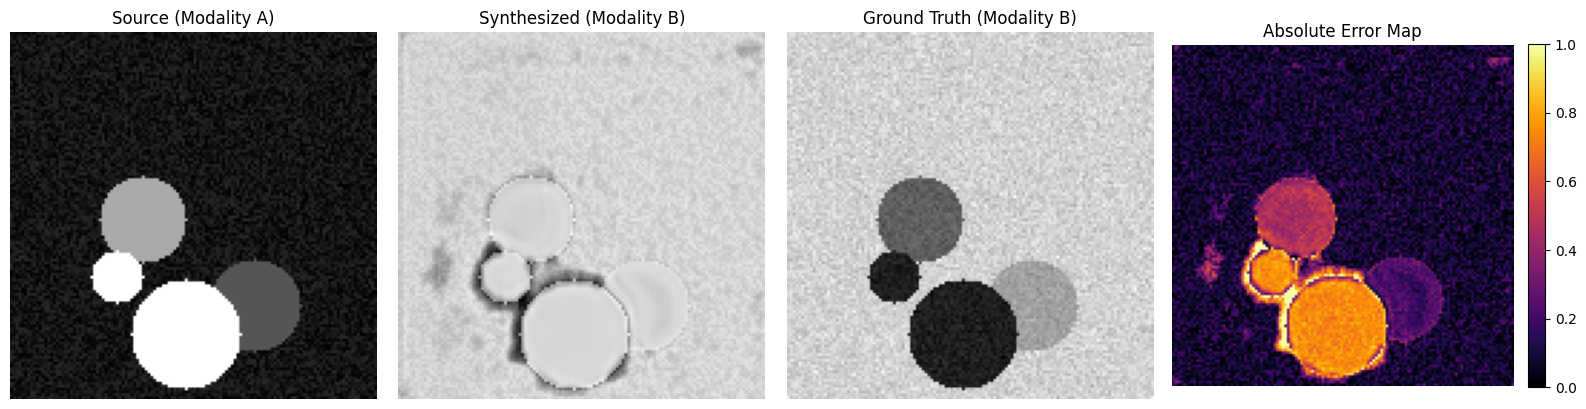

In [34]:
# Initialize metrics
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
mae_metric = MeanAbsoluteError().to(device)

# Compute
psnr_val = psnr_metric(synth_target, gt_target_img)
ssim_val = ssim_metric(synth_target, gt_target_img)
mae_val = mae_metric(synth_target.flatten(), gt_target_img.flatten())

print(f"Quantitative Results -> PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f} | MAE: {mae_val:.4f}")

# Visualization function
def plot_results(src, synth, gt):
    src_np = src[0, 0].cpu().numpy()
    synth_np = synth[0, 0].cpu().numpy()
    gt_np = gt[0, 0].cpu().numpy()
    error_map = np.abs(synth_np - gt_np)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    ax = axes[0]
    ax.imshow(src_np, cmap="gray")
    ax.set_title("Source (Modality A)")
    ax.axis("off")

    ax = axes[1]
    ax.imshow(synth_np, cmap="gray")
    ax.set_title("Synthesized (Modality B)")
    ax.axis("off")

    ax = axes[2]
    ax.imshow(gt_np, cmap="gray")
    ax.set_title("Ground Truth (Modality B)")
    ax.axis("off")

    ax = axes[3]
    im = ax.imshow(error_map, cmap="inferno", vmin=0, vmax=1)
    ax.set_title("Absolute Error Map")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_results(source_img, synth_target, gt_target_img)

## Section 8: Rare Pathology Augmentation (Conceptual)

A major application of SB-CFM is augmenting datasets with rare pathologies. If we insert a synthetic "lesion" or structural abnormality into a healthy Source image ($x_0$), we can map it through the learned vector field to observe how the modality translation preserves the novel geometry.

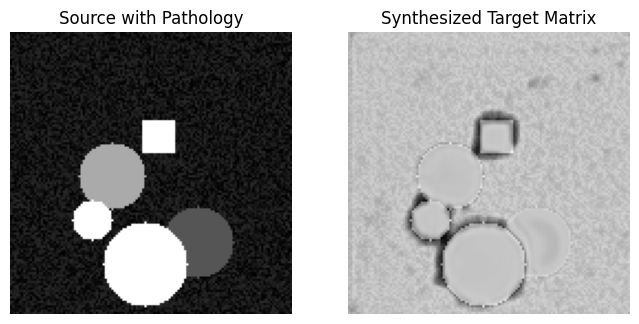

In [35]:
# Create a simulated "rare pathology" (e.g., a hyperintense tumor) in the source image
source_pathology = source_img.clone()
# Insert a bright square lesion
source_pathology[0, 0, 40:55, 60:75] = 1.0

# Push the modified source through the learned Schrödinger Bridge
synth_pathology = generate_target(model, source_pathology, steps=20)

# Visualize structural preservation
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(source_pathology[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Source with Pathology")
axes[0].axis("off")

axes[1].imshow(synth_pathology[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title("Synthesized Target Matrix")
axes[1].axis("off")

plt.show()

---

## Summary of Advantages

By choosing **Schrödinger Bridge Flow Matching (SB-CFM)** over standard architectures for cross-modal medical synthesis, we gain several critical benefits:

1. **Straighter Probability Paths**: Standard Diffusion Models wander through a curved, noisy Gaussian space. SB-CFM models Optimal Transport (OT) paths, meaning the transformation from Modality A to Modality B is essentially a straight line.
2. **Fewer Inference Steps**: Because the paths are straight, the ODE solver can take much larger step sizes. We can often synthesize high-fidelity images in 10-20 steps, compared to the 100-1000 steps required by traditional DDPMs.
3. **Paired Direct Transport**: Unlike CycleGAN, which relies on adversarial training (which is prone to mode collapse and hallucination of non-anatomical structures), SB-CFM leverages paired data to enforce rigid structural consistency, a strict requirement in medical imaging.
4. **No Gaussian Intermediate**: We bypass the necessity of mapping data to pure noise and back. We directly map Data $\to$ Data.